# Fraud Detection

Goal: Identify fraudulent transactions.

Key focus: High **Recall**, since missing fraud = financial loss.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import recall_score, roc_auc_score, classification_report, confusion_matrix

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [3]:
train.shape

(300113, 21)

In [4]:
test.shape

(99887, 21)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  object 
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  object 
 11  device_type                      300113 non-null  object 
 12  is

In [6]:
print(train.isnull().sum())

transaction_id                     0
transaction_time                   0
customer_id                        0
merchant_id                        0
account_age_days                   0
credit_score_band                  0
kyc_level                          0
avg_monthly_spend                  0
merchant_risk_score                0
transaction_amount                 0
payment_channel                    0
device_type                        0
is_international                   0
ip_risk_score                      0
txn_count_1h                       0
txn_count_24h                      0
failed_txn_count_24h               0
geo_distance_from_last_txn         0
amount_deviation_from_user_mean    0
is_fraud                           0
post_auth_risk_score               0
dtype: int64


In [7]:
train["is_fraud"].value_counts()

is_fraud
0    295242
1      4871
Name: count, dtype: int64

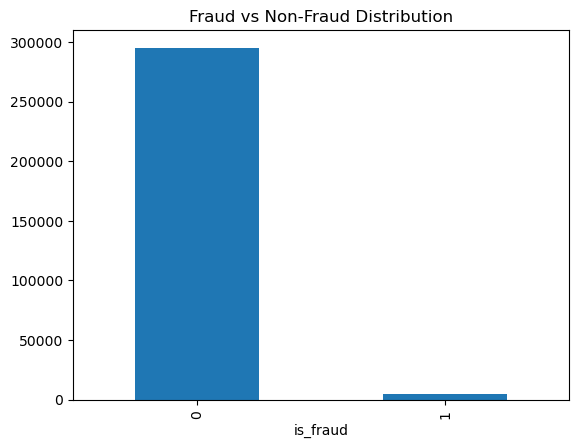

In [8]:
train["is_fraud"].value_counts().plot(kind= "bar")
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

## Imbalance Handling
Data is highly imbalanced so will use class weights and scale_pos_weight to give importance to fraud cases.

In [9]:
test["is_fraud"].value_counts()

is_fraud
0    97904
1     1983
Name: count, dtype: int64

In [10]:
train_df = train.copy()
test_df = test.copy()

train_df.head(3)

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,02:00.3,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,02:26.3,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,06:54.1,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647


In [11]:
train_df["payment_channel"].value_counts()

payment_channel
card             149765
upi               75108
wallet            45176
bank_transfer     30064
Name: count, dtype: int64

In [12]:
test_df["payment_channel"].value_counts()

payment_channel
card             49943
upi              25042
wallet           14994
bank_transfer     9908
Name: count, dtype: int64

In [14]:
train_df["device_type"].value_counts()

device_type
mobile     210051
desktop     75080
tablet      14982
Name: count, dtype: int64

In [15]:
test_df["device_type"].value_counts()

device_type
mobile     69767
desktop    25084
tablet      5036
Name: count, dtype: int64

In [16]:
train_df = pd.get_dummies(train_df, columns=["payment_channel", "device_type"], drop_first= True, dtype= int)
test_df = pd.get_dummies(test_df, columns=["payment_channel", "device_type"], drop_first= True, dtype= int)

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

train_df.head(3)

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score,payment_channel_card,payment_channel_upi,payment_channel_wallet,device_type_mobile,device_type_tablet
0,359131,02:00.3,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,1,33.458018,2205.262235,0,0.099920,0,0,1,0,0
1,351207,02:26.3,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,0,3.375083,2638.786943,0,0.291715,0,0,0,1,0
2,10209,06:54.1,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,0,13.732603,1305.843886,0,0.216647,1,0,0,0,0


In [17]:
train_df.columns.equals(test_df.columns)

True

In [18]:
print(train_df.columns)

Index(['transaction_id', 'transaction_time', 'customer_id', 'merchant_id',
       'account_age_days', 'credit_score_band', 'kyc_level',
       'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount',
       'is_international', 'ip_risk_score', 'txn_count_1h', 'txn_count_24h',
       'failed_txn_count_24h', 'geo_distance_from_last_txn',
       'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score',
       'payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet',
       'device_type_mobile', 'device_type_tablet'],
      dtype='object')


In [19]:
train_df['transaction_time'].str.split(':').str[0].astype(int).max()  

59

In [20]:
def process_time(df):
   
    df['time_only'] = df['transaction_time'].astype(str).str.split().str[-1]
    
    df['hour'] = df['time_only'].str.split(':').str[0].astype(int)
    df['minute'] = df['time_only'].str.split(':').str[1].str.split('.').str[0].astype(int)
    
    df['time_in_hours'] = df['hour'] + df['minute'] / 60
    
    df.drop(['transaction_time', 'time_only'], axis=1, inplace=True)
    
    return df

In [21]:
train_df = process_time(train_df)
test_df = process_time(test_df)

In [22]:
train_df.head()

,transaction_id,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,...,is_fraud,post_auth_risk_score,payment_channel_card,payment_channel_upi,payment_channel_wallet,device_type_mobile,device_type_tablet,hour,minute,time_in_hours
0,359131,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,0,...,0,0.099920,0,0,1,0,0,2,0,2.000000
1,351207,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,0,...,0,0.291715,0,0,0,1,0,2,26,2.433333
2,10209,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,0,...,0,0.216647,1,0,0,0,0,6,54,6.900000
3,62660,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,0,...,0,0.354154,1,0,0,1,0,6,57,6.950000
4,384254,3979,1555,360,2,3,5082.651983,0.171230,986.397163,0,...,0,0.149084,1,0,0,1,0,8,5,8.083333


In [23]:
print(train_df.columns)

Index(['transaction_id', 'customer_id', 'merchant_id', 'account_age_days',
       'credit_score_band', 'kyc_level', 'avg_monthly_spend',
       'merchant_risk_score', 'transaction_amount', 'is_international',
       'ip_risk_score', 'txn_count_1h', 'txn_count_24h',
       'failed_txn_count_24h', 'geo_distance_from_last_txn',
       'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score',
       'payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet',
       'device_type_mobile', 'device_type_tablet', 'hour', 'minute',
       'time_in_hours'],
      dtype='object')


In [24]:
print(test_df.columns)

Index(['transaction_id', 'customer_id', 'merchant_id', 'account_age_days',
       'credit_score_band', 'kyc_level', 'avg_monthly_spend',
       'merchant_risk_score', 'transaction_amount', 'is_international',
       'ip_risk_score', 'txn_count_1h', 'txn_count_24h',
       'failed_txn_count_24h', 'geo_distance_from_last_txn',
       'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score',
       'payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet',
       'device_type_mobile', 'device_type_tablet', 'hour', 'minute',
       'time_in_hours'],
      dtype='object')


In [25]:
X_train= train_df.drop(columns= ["is_fraud", 
                                 "transaction_id", 
                                 "customer_id",  
                                 "post_auth_risk_score",
                                 "minute"],
                      axis= 1)
y_train= train_df["is_fraud"]

In [26]:
X_test= test_df.drop(columns= ["is_fraud", 
                                 "transaction_id", 
                                 "customer_id",  
                                 "post_auth_risk_score",
                                 "minute"],
                      axis= 1)
y_test= test_df["is_fraud"]

In [27]:
X_train.columns.equals(X_test.columns)

True

In [28]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size= 0.2, random_state= 42, stratify= y_train   
)

In [29]:
scaler= StandardScaler()

X_train_final_scaled = scaler.fit_transform(X_train_final) 
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (Baseline Model)

In [30]:
log_reg = LogisticRegression(class_weight='balanced', 
                             solver='liblinear', 
                             max_iter= 100
)
log_reg.fit(X_train_final_scaled, y_train_final)

y_pred = log_reg.predict(X_val_scaled)
y_prob = log_reg.predict_proba(X_val_scaled)[:, 1]

print("Recall:", recall_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Recall: 0.7258726899383984

Confusion Matrix:
 [[47040 12009]
 [  267   707]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.80      0.88     59049
           1       0.06      0.73      0.10       974

    accuracy                           0.80     60023
   macro avg       0.52      0.76      0.49     60023
weighted avg       0.98      0.80      0.87     60023



# Random Forest

In [31]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4]
}
random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter= 15,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state= 42
)
random_rf.fit(X_train_final, y_train_final)

best_rf = random_rf.best_estimator_

print("Best RF Params:", random_rf.best_params_)

# Default prediction
y_pred = best_rf.predict(X_val)

print("\n--- Default RF ---")
print("Recall:", recall_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))


# Threshold tuned prediction
y_prob_rf = best_rf.predict_proba(X_val)[:, 1]
y_pred_thresh = (y_prob_rf > 0.3).astype(int)

print("\n--- RF After Threshold (0.3) ---")
print("Recall:", recall_score(y_val, y_pred_thresh))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_thresh))
print("\nClassification Report:\n", classification_report(y_val, y_pred_thresh))

Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None}

--- Default RF ---
Recall: 0.22587268993839835

Confusion Matrix:
 [[58849   200]
 [  754   220]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     59049
           1       0.52      0.23      0.32       974

    accuracy                           0.98     60023
   macro avg       0.76      0.61      0.65     60023
weighted avg       0.98      0.98      0.98     60023


--- RF After Threshold (0.3) ---
Recall: 0.3726899383983573

Confusion Matrix:
 [[58344   705]
 [  611   363]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     59049
           1       0.34      0.37      0.36       974

    accuracy                           0.98     60023
   macro avg       0.66      0.68      0.67     60023
weighted avg       0.98      0.98   

# XGBoost

In [32]:
neg = (y_train_final == 0).sum()
pos = (y_train_final == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    scale_pos_weight = neg / pos
)
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'eval_metric': ['logloss']
}
grid_xgb = GridSearchCV(
    estimator= xgb_model,
    param_grid= param_grid_xgb,
    scoring= 'f1',
    cv= 3,
    n_jobs= -1
)
grid_xgb.fit(X_train_final, y_train_final)

best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)

# Default prediction
y_pred = best_xgb.predict(X_val)
y_prob = best_xgb.predict_proba(X_val)[:, 1]

print("\n--- XGBoost Default ---")
print("Recall:", recall_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# THRESHOLD TUNING
thresholds = [0.2, 0.3, 0.4]

for t in thresholds:
    y_pred_thresh = (y_prob > t).astype(int)
    
    print(f"\n--- XGBoost Threshold {t} ---")
    print("Recall:", recall_score(y_val, y_pred_thresh))
    print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_thresh))
    print("Classification Report:\n", classification_report(y_val, y_pred_thresh))

Best XGB Params: {'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

--- XGBoost Default ---
Recall: 0.5985626283367557
ROC-AUC: 0.8021758579856224

Confusion Matrix:
 [[53873  5176]
 [  391   583]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95     59049
           1       0.10      0.60      0.17       974

    accuracy                           0.91     60023
   macro avg       0.55      0.76      0.56     60023
weighted avg       0.98      0.91      0.94     60023


--- XGBoost Threshold 0.2 ---
Recall: 0.8357289527720739

Confusion Matrix:
 [[27936 31113]
 [  160   814]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.47      0.64     59049
           1       0.03      0.84      0.05       974

    accuracy                           0.48     60023
   macro avg       0.51      0.65      0.35     60023
weighted 

## Threshold
Using threshold = 0.3 (instead of 0.5) to increase Recall and catch more fraud cases.

## Confusion Matrix
Focus is on reducing False Negatives (missed fraud), even if False Positives increase.

In [33]:
def evaluate_model(model, X, y, model_name):
    y_prob = model.predict_proba(X)[:,1]
    y_pred = (y_prob > 0.3).astype(int)

    print(f"\n--- {model_name} ---")
    print("Recall:", recall_score(y, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\nClassification Report:\n", classification_report(y, y_pred))

In [34]:
evaluate_model(log_reg, X_val_scaled, y_val, "Logistic Regression")
evaluate_model(best_rf, X_val, y_val, "Random Forest")
evaluate_model(best_xgb, X_val, y_val, "XGBoost")


--- Logistic Regression ---
Recall: 0.8347022587268994

Confusion Matrix:
 [[30249 28800]
 [  161   813]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.51      0.68     59049
           1       0.03      0.83      0.05       974

    accuracy                           0.52     60023
   macro avg       0.51      0.67      0.36     60023
weighted avg       0.98      0.52      0.67     60023


--- Random Forest ---
Recall: 0.3726899383983573

Confusion Matrix:
 [[58344   705]
 [  611   363]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     59049
           1       0.34      0.37      0.36       974

    accuracy                           0.98     60023
   macro avg       0.66      0.68      0.67     60023
weighted avg       0.98      0.98      0.98     60023


--- XGBoost ---
Recall: 0.7197125256673511

Confusion Matrix:
 [[44854 14195]
 [  273  

In [35]:
y_test

0        0
1        0
2        0
3        0
4        0
        ..
99882    0
99883    0
99884    0
99885    1
99886    0
Name: is_fraud, Length: 99887, dtype: int64

# EVALUATE ON TEST DATA

In [36]:
y_prob_test = best_rf.predict_proba(X_test)[:, 1]
y_test_pred = (y_prob_test > 0.3).astype(int)

from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix, classification_report

print("\n--- Final Test Results (Random Forest) ---")
print("Recall:", recall_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


--- Final Test Results (Random Forest) ---
Recall: 0.34140191628845185
ROC-AUC: 0.8236610717162229

Confusion Matrix:
 [[96865  1039]
 [ 1306   677]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     97904
           1       0.39      0.34      0.37      1983

    accuracy                           0.98     99887
   macro avg       0.69      0.67      0.68     99887
weighted avg       0.97      0.98      0.98     99887



# Final Conclusion

- Logistic Regression served as a baseline model but suffered from low precision.
- XGBoost achieved high recall but produced many false positives.
- Random Forest provided the best balance between precision and recall after threshold tuning.

On unseen test data, Random Forest achieved good recall with a ROC-AUC score of ~0.82, making it suitable for fraud detection tasks where identifying fraud is critical.

This project highlights the importance of handling class imbalance and tuning thresholds in fraud detection systems.